Assignment no : 05

Roll no : 13216 

Problem Statement :
Data Analytics II
1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision,
Recall on the given dataset.

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Load Dataset

In [3]:
dataset = pd.read_csv("Social_Network_Ads (1).csv")
print(dataset.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


Select Features (X) and Target (y)

In [4]:
X = dataset.iloc[:, [2, 3]].values   # Age & Salary
y = dataset.iloc[:, 4].values        # Purchased (0/1)

Split Dataset (Training & Testing)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

Feature Scaling (Important)

In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Apply Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Predict Results

In [8]:
y_pred = model.predict(X_test)

Create Confusion Matrix

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 8 24]]


Extract Values

In [10]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [11]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

In [12]:
error_rate = 1 - accuracy

In [13]:
precision = TP / (TP + FP)

In [14]:
recall = TP / (TP + FN)

In [15]:
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

TP: 24
TN: 65
FP: 3
FN: 8
Accuracy: 0.89
Error Rate: 0.10999999999999999
Precision: 0.8888888888888888
Recall: 0.75


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



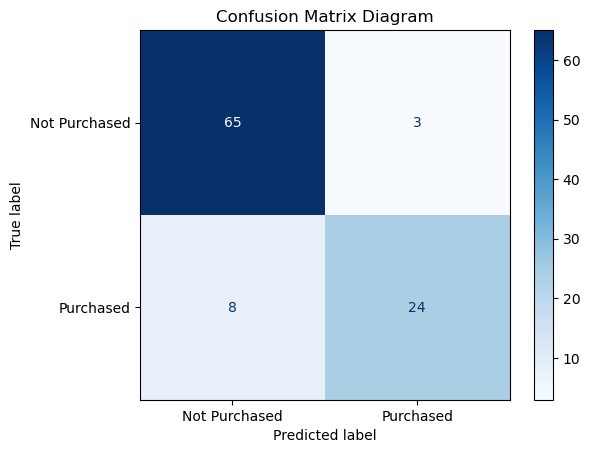

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display diagram
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Purchased", "Purchased"])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix Diagram")
plt.show()